# Compute properties from known data

In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d
import xarray as xr

plt.rcParams["font.family"] = "FreeSerif"
plt.rcParams["mathtext.fontset"] = "cm"

In [12]:
def _xy_from_df(df, var_type):
    x = df.iloc[:,0].to_numpy().squeeze()
    y = df.iloc[:,1].to_numpy().squeeze()
    order = np.argsort(x)

    if var_type != 'Z': # If the variable is not the altitude below the flight level then the minimum value is zero
        negative_y_indices = np.where(y < 0)[0]
        if negative_y_indices.size > 0:
            print(f"Warning: Found negative y values at indices {negative_y_indices}. Setting them to zero.")
            y[negative_y_indices] = 0.0

    return x[order], y[order]

def compute_depth(LES_Zt, LES_max_depth, times, t_fall_subsat):
    """
    Compute contrail depth from LES_Zt [m], LES_max_depth [m], times [hr], and t_fall_subsat [hr].
    """
    z = np.asarray(LES_Zt) * -1 # Convert to absolute altitude below flight level [m]
    depth = np.zeros_like(times)

    # Depth increases linearly until the fall time is reached
    for i in range(len(times)):
        time = times[i]
        if time < t_fall_subsat:
            intercept = 100 # [m], match initial depth to APCEMM bypass data
            slope = (LES_max_depth - intercept)/t_fall_subsat
            depth[i] = slope*time + intercept
        else:
            depth[i] = depth[i-1] - (z[i]-z[i-1])  # Decrease depth as contrail descends into subsaturated air
            if depth[i] < depth[0]:  # Prevent depth from decreasing below initial depth
                depth[i] = depth[i-1]  # Prevent negative depth

    return depth

def compute_width(LES_depth, times, dudz, lifetime, t_max_width):
    """
    Compute contrail width from LES_depth [m], times [hr], dudz [m/s/m], and lifetime [hr].
    """
    # If the width is the max width, use the max width formula
    width = np.zeros_like(times)
    c4 = 0.25 # empirical constant from Lewellen 2014 pt 2
    max_width = c4*(dudz/1000)*LES_depth.max()*lifetime*3600 # [m/sm] * [m] * [s] = [m]
    print(f"Max width: {max_width:.2f} m")

    # Linear growth until max width is reached, then linear decrease
    for i in range(len(times)):
        time = times[i]
        if time <= t_max_width:
            zero_intercept = 10 # [m], match initial width to APCEMM bypass data
            slope = (max_width - zero_intercept)/(t_max_width)
            width[i] = slope*time + zero_intercept
        else:
            slope = (max_width - zero_intercept)/(t_max_width) * -1  # Negative slope for linear decrease
            intercept = max_width - (slope * t_max_width)  # Adjust intercept to ensure continuity at t_max_width
            width[i] = slope*time + intercept
    
    return width

def alt_to_pres(altitude):
    """
    Convert altitude (m) to pressure (Pa) using the U.S. Standard Atmosphere 1976
    piecewise layer formulation. Accepts scalar or array-like altitude in meters.
    """
    h = np.asarray(altitude).astype(float)  # meters
    shape = h.shape
    h_flat = h.ravel()

    # US Standard Atmosphere layer bases (geometric heights in meters),
    # base temperatures (K), lapse rates (K/m)
    h_b = np.array([0.0, 11000.0, 20000.0, 32000.0, 47000.0, 51000.0, 71000.0, 84852.0])
    T_b = np.array([288.15, 216.65, 216.65, 228.65, 270.65, 270.65, 214.65, 186.946])
    L_b = np.array([-0.0065, 0.0, 0.0010, 0.0028, 0.0, -0.0028, -0.0020, 0.0])

    # Precompute base pressures at layer bottoms by stepping from sea level
    P0 = 101325.0
    g0 = 9.80665
    R = 287.05

    P_b = np.empty_like(h_b)
    P_b[0] = P0
    for i in range(1, len(h_b)):
        hb0 = h_b[i-1]
        hb1 = h_b[i]
        Tb0 = T_b[i-1]
        L = L_b[i-1]
        if L == 0.0:
            P_b[i] = P_b[i-1] * np.exp(-g0 * (hb1 - hb0) / (R * Tb0))
        else:
            P_b[i] = P_b[i-1] * (Tb0 / (Tb0 + L * (hb1 - hb0))) ** (g0 / (R * L))

    # compute pressure for each altitude
    p_flat = np.empty_like(h_flat)
    for idx, hi in enumerate(h_flat):
        # below minimum, use sea level; above last layer, extrapolate using last layer lapse rate
        if hi < 0:
            hi = 0.0
        # find layer
        layer = np.searchsorted(h_b, hi, side='right') - 1
        if layer < 0:
            layer = 0
        if layer >= len(h_b) - 1:
            layer = len(h_b) - 1

        hb0 = h_b[layer]
        Tb0 = T_b[layer]
        L = L_b[layer]
        Pb0 = P_b[layer]
        dh = hi - hb0

        if L == 0.0:
            p_flat[idx] = Pb0 * np.exp(-g0 * dh / (R * Tb0))
        else:
            p_flat[idx] = Pb0 * (Tb0 / (Tb0 + L * dh)) ** (g0 / (R * L))

    return p_flat.reshape(shape)

# Clip negative values to zero after interpolation
def clip_negative_values(func, times):
    values = np.asarray(func(times)).copy()
    values[values < 0] = 0.0
    return values

In [13]:
test_ids = ['110T205L25', '110T218L25', '110T225L25', '130T205L25', '130T218L25', '130T225L25']


In [14]:
for test_id in test_ids:
    RHi = float(test_id.split('T')[0])  # % relative humidity
    T = int(test_id.split('T')[1].split('L')[0])  # Kelvin

    print(f"Processing LES data for test case: {test_id} with RHi={RHi}%, T={T}K")
    # Import LES Z(t) data
    LES_Zt = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/mean_altitude/{test_id}_Z.csv")
    LES_ice_mass = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_mass/{test_id}.csv", header=None)
    LES_ice_num = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_crystal_number/{test_id}.csv", header=None)
    LES_ice_surface_area = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/raw_data_from_plots/ice_surface_area/{test_id}_S.csv", header=None)
    
    # Read-in data already done above; now build a common 10-minute grid and interpolate each series onto it.
    # Assumes first column = time (hours) and second column = value.
    
    # extract and sort (time, value) pairs
    t_z, z = _xy_from_df(LES_Zt, 'Z')
    t_m, m = _xy_from_df(LES_ice_mass, 'mass')
    t_n, n = _xy_from_df(LES_ice_num, 'number')
    t_s, s = _xy_from_df(LES_ice_surface_area, 'surface_area')
    
    # common time range (based on overall min/max) and 10-minute increments (hours)
    dt = 10/60  # hours
    t_min = 0
    
    # Determine t_end: first time AFTER the mass reaches its maximum when mass is 1% of max
    # index of peak (ignore NaNs if any)
    peak_idx = int(np.argmax(LES_ice_mass[1]))
    t_peak = LES_ice_mass[0][peak_idx]
    threshold = 0.01 * LES_ice_mass[1][peak_idx]
    print(f"Index of peak mass: {peak_idx}, Time of peak mass: {t_peak:.2f} hours, Mass at peak: {LES_ice_mass[1][peak_idx]:.4f}, Threshold for end time: {threshold:.4f}")
    
    post_peak_idxs = np.where((LES_ice_mass[0] > t_peak) & (LES_ice_mass[1] <= threshold))[0]
    if post_peak_idxs.size > 0:
        t_end = float(LES_ice_mass[0][post_peak_idxs[0]])
    else:
        # fallback to end of available times
        t_end = float(LES_ice_mass[0][-1])
    
    times = np.arange(t_min, t_end + 1e-12, dt) # [hours]
    print(f"t_end: {t_end:.2f} hours, t_end index: {post_peak_idxs[0] if post_peak_idxs.size > 0 else 'N/A'}")
    
    # interpolation functions (allow extrapolation to cover full range)
    fz = interp1d(t_z, z, kind='linear', bounds_error=False, fill_value='extrapolate')
    fm = interp1d(t_m, m, kind='linear', bounds_error=False, fill_value='extrapolate')
    fn = interp1d(t_n, n, kind='linear', bounds_error=False, fill_value='extrapolate')
    fs = interp1d(t_s, s, kind='linear', bounds_error=False, fill_value='extrapolate')
    
    # interpolated series (overwrite/use names needed by downstream cells)
    LES_Zt = fz(times)                      # depth/time series (array)
    LES_ice_mass = clip_negative_values(fm, times)                # ice mass (array)
    LES_ice_num = clip_negative_values(fn, times)            # overwrite with interpolated number concentration (array)
    LES_ice_surface_area = clip_negative_values(fs, times)        # surface area (array)

    LES_max_depth = 610 # Meters
    dudz = 4 # m/s/km
    lifetime = t_end  # hours
    mean_altitude = 10700 + LES_Zt

    ### Calculate effective radius
    r_eff = (((LES_ice_surface_area/LES_ice_num)/(4*3.1415))**(0.5))*1e6  # Convert to micrometers
    r_eff_inf_indices = np.isinf(r_eff)
    # replace inf/-inf/nan with the last finite value (fallback to next finite or 0.0)
    mask = ~np.isfinite(r_eff)
    if np.any(mask):
        bad_idxs = np.where(mask)[0]
        print(f"Warning: Found non-finite effective radius at indices {bad_idxs}. Replacing with last valid values.")
        for i in bad_idxs:
            j = i - 1
            while j >= 0 and not np.isfinite(r_eff[j]):
                j -= 1
            if j >= 0:
                r_eff[i] = r_eff[j]
            else:
                k = i + 1
                while k < r_eff.size and not np.isfinite(r_eff[k]):
                    k += 1
                r_eff[i] = r_eff[k] if k < r_eff.size else 0.0
    if "110T205" in test_id:
        r_eff[0] = 1.2 # Match with reported suater mean of distribution
    elif "225" in test_id:
        r_eff[0] = 5.8 # Match with reported sauter mean of distribution

    ### Calculate the time required for an ice crystal to fall into the subsaturated layer
    g = 9.81  # m/s²
    rho_ice = 917  # kg/m³
    rho_air = 0.378  # kg/m³ at 10 km altitude
    miu = 1.48e-5  # kg/(m·s), dynamic viscosity of air at 10 km altitude
    lambda_air = 0.066e-6  * (T/293) * (1013/225)# m, mean free path of air molecules at 10 km altitude
    Kn = lambda_air/(r_eff*1e-6) # Knudsen number
    Cc = 1 + Kn*(1.257 + 0.4*np.exp(-1.1/Kn))  # Cunningham slip correction factor, where Kn is the Knudsen number
    weak_BV = 0.05 # m/s, a small settling velocity
    u_term = Cc* (2/9 * (r_eff*1e-6)**2 * (g *(rho_ice-rho_air))/miu) + weak_BV # m/s
    distance_fallen = 0 # m
    dt = times[1] - times[0] # hours
    i = 0
    layer_depth = 500 # m, depth of subsaturated layer below flight level

    while distance_fallen < layer_depth and i < len(u_term):

        distance_fallen += u_term[i] * dt * 3600  # Convert hours to seconds for velocity*time
        time_to_subsat = times[i]
        i += 1
    print(f"Calculated time to fall into subsaturated layer (hours): {time_to_subsat}")

    ### Find the time when the mean contrail mass reaches the subsaturated layer
    if np.any(LES_Zt <= layer_depth * -1):
        idx = np.where(LES_Zt <= layer_depth * -1)[0][0]
        if idx == 0:
            t_max_width = times[0]
        else:
            t_max_width = np.interp(layer_depth * -1, LES_Zt[idx-1:idx+1][::-1], times[idx-1:idx+1][::-1])
        print(f"{test_id}: Z reaches -500 m at ~{t_max_width:.2f} hours.")
    else:
        print(f"{test_id}: Z does not reach -500 m within available data.")
    
    ### Calculate contrail depths
    LES_depth = compute_depth(LES_Zt, LES_max_depth, times, time_to_subsat) # [m]
    
    ### Calculate contrail width
    LES_width = compute_width(LES_depth, times, dudz, lifetime, t_max_width)
    
    ### Calculate contrail area
    LES_area = np.pi * LES_width * LES_depth / 4

    ### Calculate ice water content
    LES_IWC = LES_ice_mass/LES_area * 1e3 # [kg/m]/[m2] * 1e3 = [g/m3]

    # Save the LLES IWC data to a CSV file
    LLES_iwc_df = pd.DataFrame({'Time_hours': times, 
                                'IWC_g_per_m3': LES_IWC, 
                                'Depth_m': LES_depth, 
                                'Width_m': LES_width, 
                                'Effective_radius_um': r_eff, 
                                'Ice_mass': LES_ice_mass, 
                                'Ice_number': LES_ice_num, 
                                'Ice_surface_area': LES_ice_surface_area,
                                'Mean_altitude_m': mean_altitude,
                                'Area_m2': LES_area})

    LLES_iwc_df.to_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/{test_id}.csv", index=False)

Processing LES data for test case: 110T205L25 with RHi=110.0%, T=205K
Index of peak mass: 15, Time of peak mass: 7.25 hours, Mass at peak: 2.2322, Threshold for end time: 0.0223
t_end: 35.41 hours, t_end index: 65
Calculated time to fall into subsaturated layer (hours): 2.6666666666666665
110T205L25: Z reaches -500 m at ~32.22 hours.
Max width: 73700.16 m
Processing LES data for test case: 110T218L25 with RHi=110.0%, T=218K
Index of peak mass: 8, Time of peak mass: 3.55 hours, Mass at peak: 3.5293, Threshold for end time: 0.0353
t_end: 16.44 hours, t_end index: 33
Calculated time to fall into subsaturated layer (hours): 2.333333333333333
110T218L25: Z reaches -500 m at ~15.60 hours.
Max width: 33944.11 m
Processing LES data for test case: 110T225L25 with RHi=110.0%, T=225K
Index of peak mass: 7, Time of peak mass: 3.25 hours, Mass at peak: 5.4230, Threshold for end time: 0.0542
t_end: 10.49 hours, t_end index: 26
Calculated time to fall into subsaturated layer (hours): 2.16666666666666

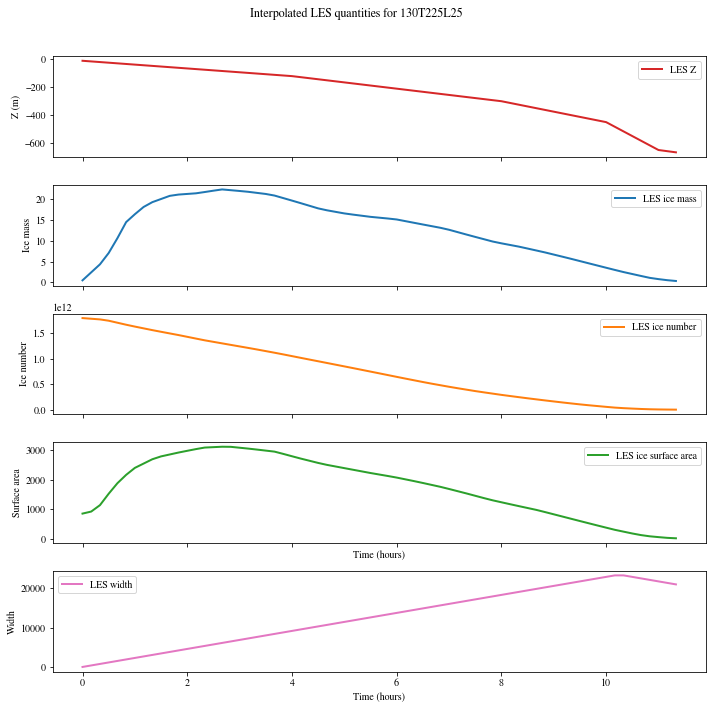

Initial contrail depth, width, and area at t=0: 100.00 m, 10.00 m, 785.40 m²
Final ice number: 1.16e+10


In [15]:
fig, axes = plt.subplots(5, 1, sharex=True, figsize=(10, 10))

axes[0].plot(times, LES_Zt, color='tab:red', lw=2, label='LES Z')
axes[0].set_ylabel('Z (m)')
axes[0].legend()

axes[1].plot(times, LES_ice_mass, color='tab:blue', lw=2, label='LES ice mass')
axes[1].set_ylabel('Ice mass')
axes[1].legend()

axes[2].plot(times, LES_ice_num, color='tab:orange', lw=2, label='LES ice number')
axes[2].set_ylabel('Ice number')
axes[2].legend()

axes[3].plot(times, LES_ice_surface_area, color='tab:green', lw=2, label='LES ice surface area')
axes[3].set_ylabel('Surface area')
axes[3].set_xlabel('Time (hours)')
axes[3].legend()

axes[4].plot(times, LES_width, color='tab:pink', lw=2, label='LES width')
axes[4].set_ylabel('Width')
axes[4].set_xlabel('Time (hours)')
axes[4].legend()

fig.suptitle(f'Interpolated LES quantities for {test_id}')
plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

print(f"Initial contrail depth, width, and area at t=0: {LES_depth[0]:.2f} m, {LES_width[0]:.2f} m, {LES_area[0]:.2f} m²")
print(f"Final ice number: {LES_ice_num[-1]:.2e}")

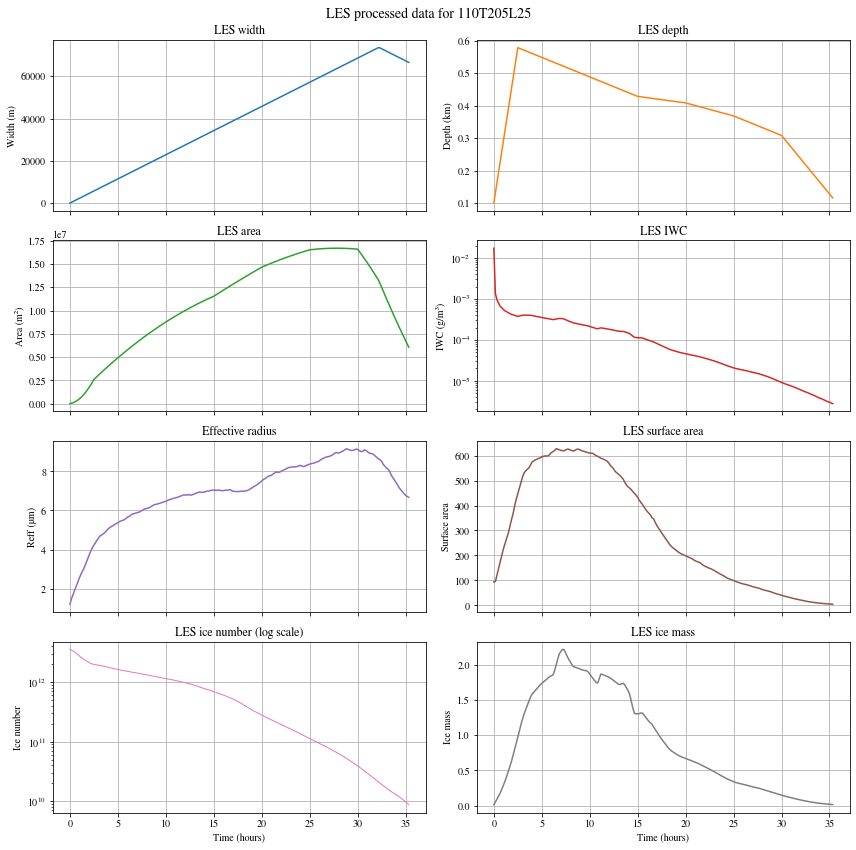

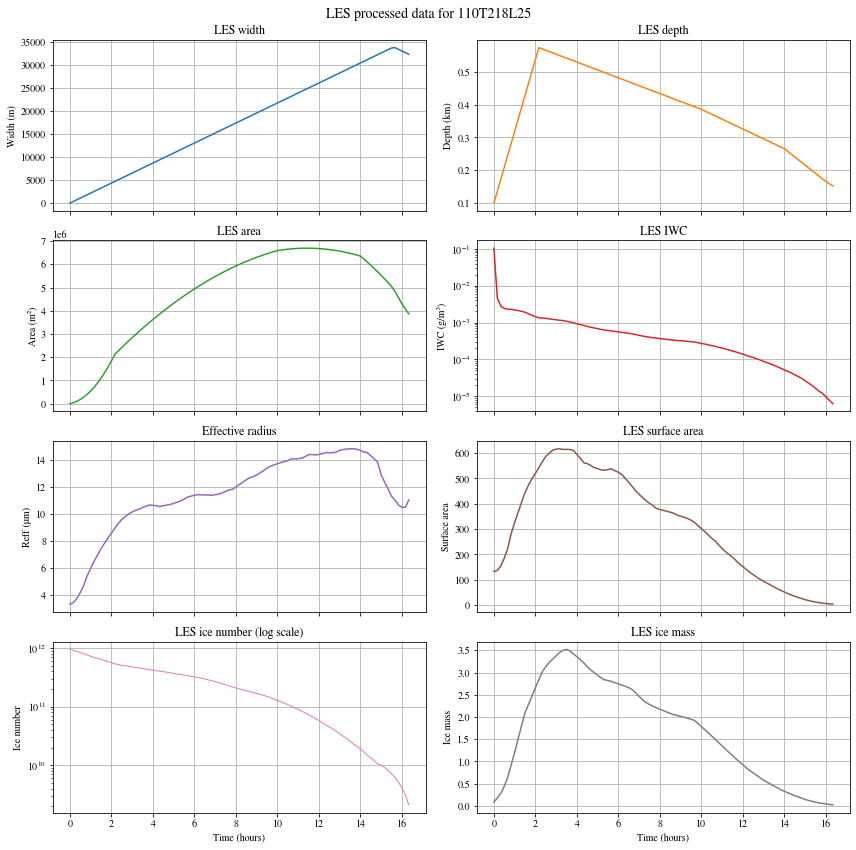

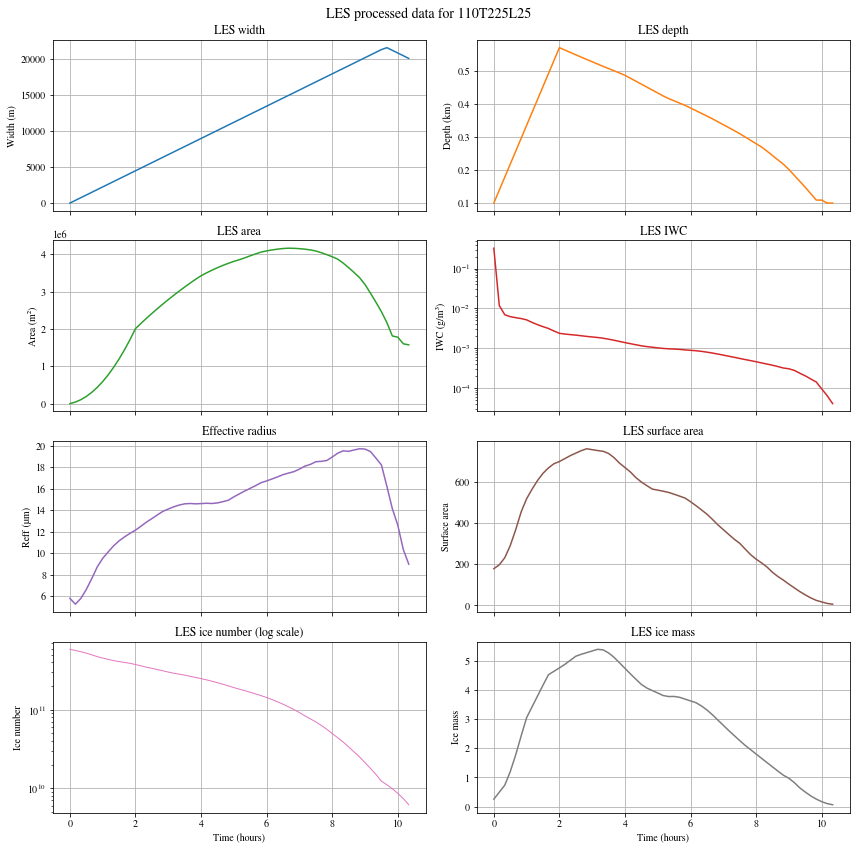

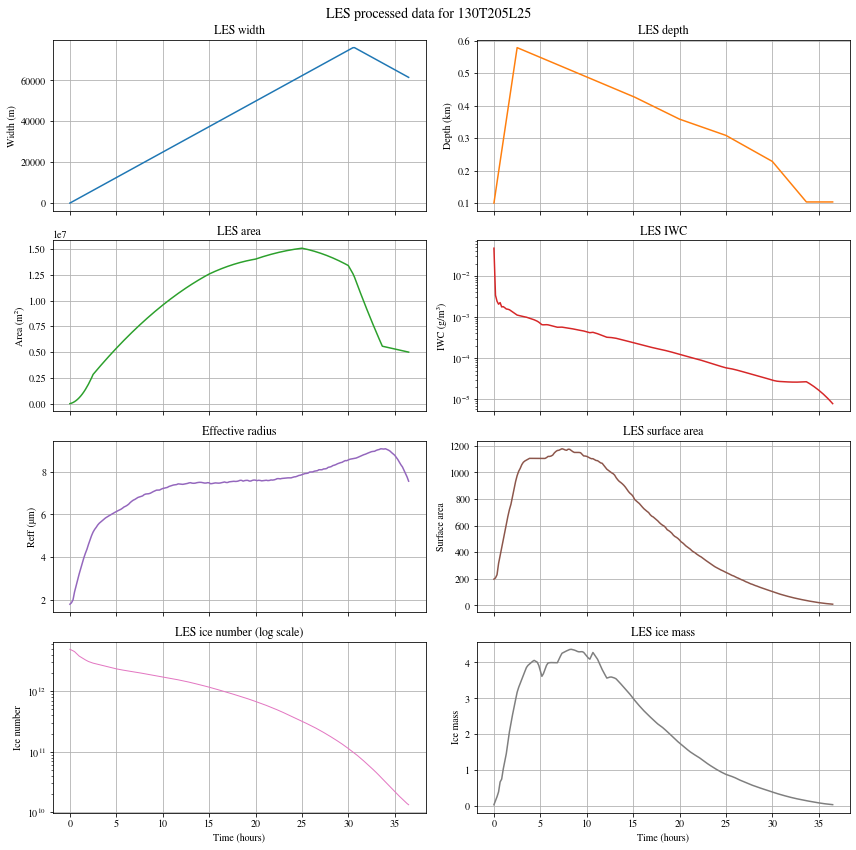

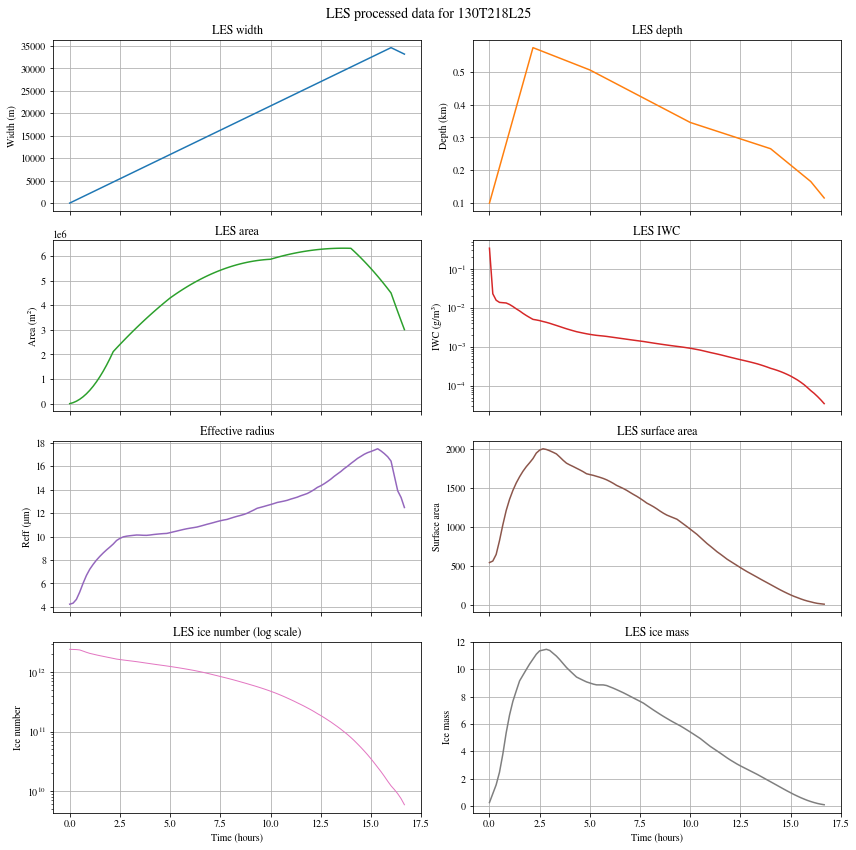

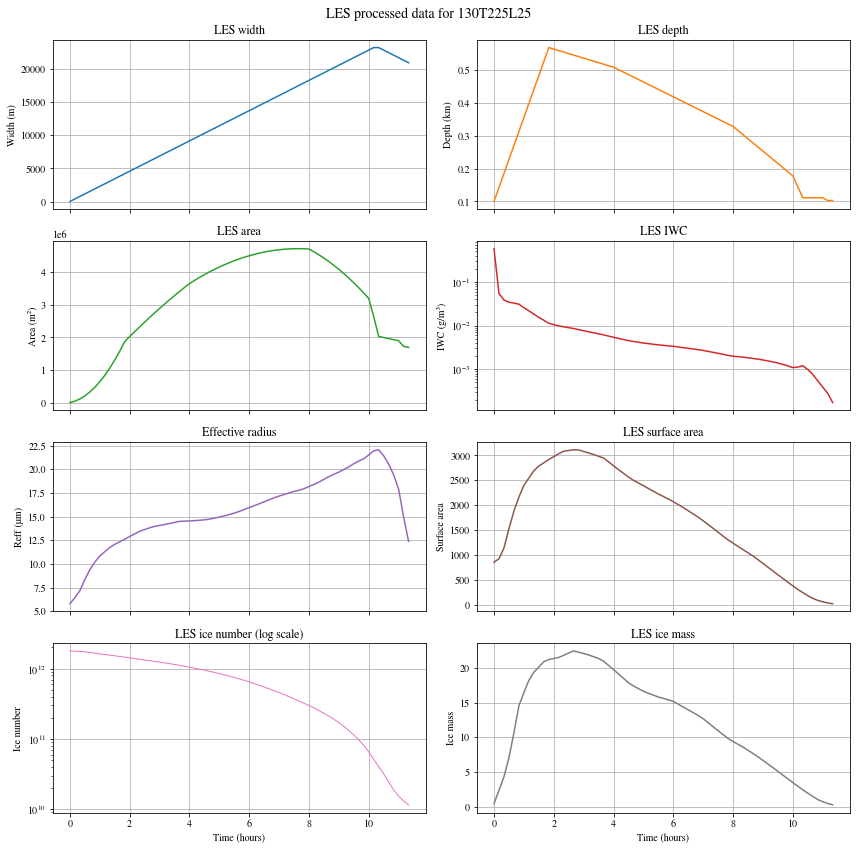

In [16]:
for test_id in test_ids:
    df = pd.read_csv(f"/home/chinahg/GCresearch/contrailuncertainty/APCEMM_vs_CoCiP_vs_LES/LES/processed_data/all_data/{test_id}.csv")
    
    times = df['Time_hours'].values
    LES_width = df['Width_m'].values
    LES_depth = df['Depth_m'].values
    LES_area = df['Area_m2'].values
    LES_IWC = df['IWC_g_per_m3'].values
    r_eff = df['Effective_radius_um'].values
    LES_ice_surface_area = df['Ice_surface_area'].values
    LES_ice_num = df['Ice_number'].values
    LES_ice_mass = df['Ice_mass'].values
    
    fig, axes = plt.subplots(4, 2, figsize=(12, 12), sharex=True)
    axs = axes.ravel()

    axs[0].plot(times, LES_width, color='C0', lw=1.5); axs[0].set_ylabel('Width (m)'); axs[0].set_title('LES width')
    axs[1].plot(times, LES_depth/1000.0, color='C1', lw=1.5); axs[1].set_ylabel('Depth (km)'); axs[1].set_title('LES depth')
    axs[2].plot(times, LES_area, color='C2', lw=1.5); axs[2].set_ylabel('Area (m²)'); axs[2].set_title('LES area')
    axs[3].plot(times, LES_IWC, color='C3', lw=1.5); axs[3].set_ylabel('IWC (g/m³)'); axs[3].set_title('LES IWC'); axs[3].set_yscale('log')
    axs[4].plot(times, r_eff, color='C4', lw=1.5); axs[4].set_ylabel('Reff (µm)'); axs[4].set_title('Effective radius')
    axs[5].plot(times, LES_ice_surface_area, color='C5', lw=1.5); axs[5].set_ylabel('Surface area'); axs[5].set_title('LES surface area')
    axs[6].plot(times, LES_ice_num, color='C6', lw=1.0); axs[6].set_ylabel('Ice number'); axs[6].set_yscale('log'); axs[6].set_title('LES ice number (log scale)')
    axs[7].plot(times, LES_ice_mass, color='C7', lw=1.5); axs[7].set_ylabel('Ice mass'); axs[7].set_title('LES ice mass')

    for a in axs:
        a.grid(True)
    axs[-1].set_xlabel('Time (hours)')
    axs[-2].set_xlabel('Time (hours)')
    
    fig.suptitle(f'LES processed data for {test_id}', fontsize=14)
    plt.tight_layout()
    plt.show()

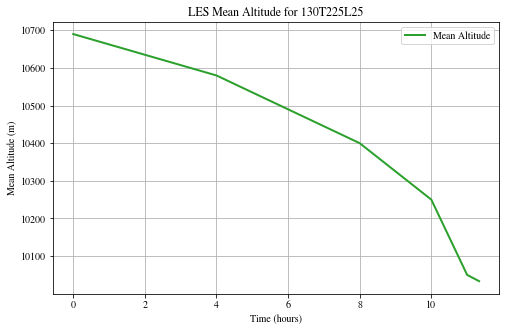

In [17]:
# Plot the mean altitude
plt.figure(figsize=(8, 5))
plt.plot(times, 10700 + LES_Zt, color='tab:green', lw=2, label='Mean Altitude')
plt.xlabel('Time (hours)')
plt.ylabel('Mean Altitude (m)')
plt.title(f'LES Mean Altitude for {test_id}')
plt.legend()
plt.grid(True)
plt.show()

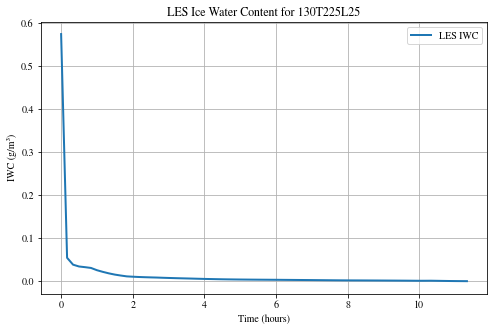

In [18]:
# Plot the LES IWC
plt.figure(figsize=(8, 5))
plt.plot(times, LES_IWC, color='tab:blue', lw=2, label='LES IWC')
plt.xlabel('Time (hours)')
plt.ylabel('IWC (g/m³)')
plt.title(f'LES Ice Water Content for {test_id}')
plt.legend()
plt.grid(True)
plt.show()